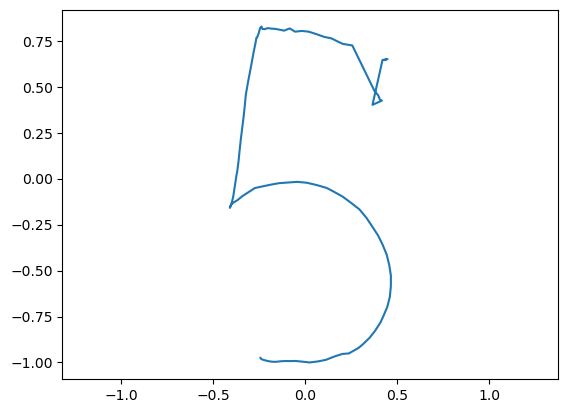

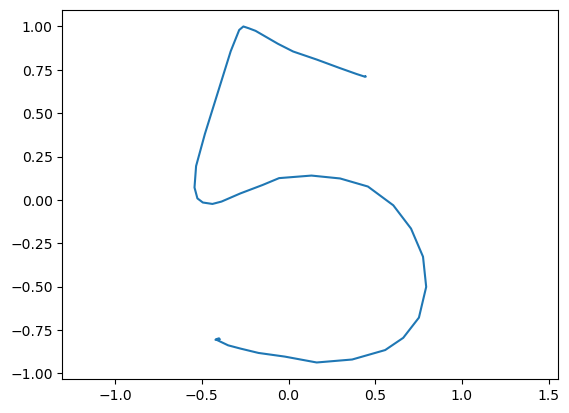

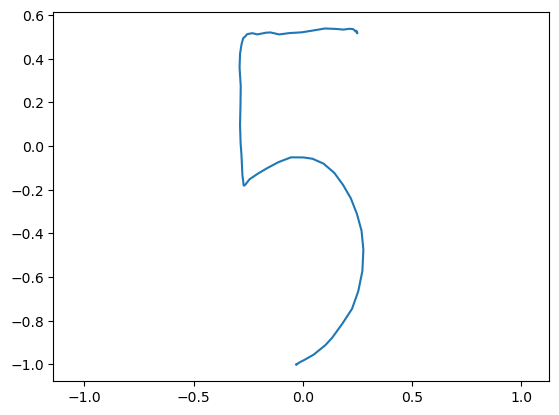

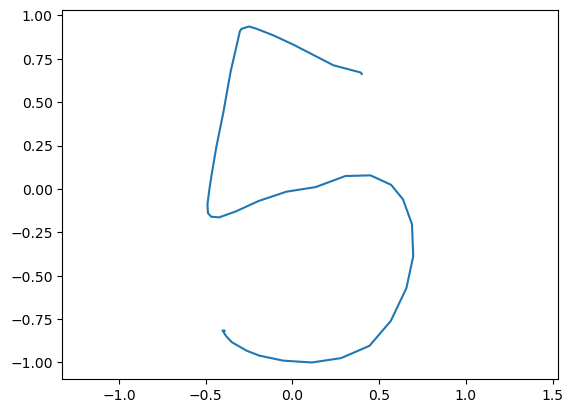

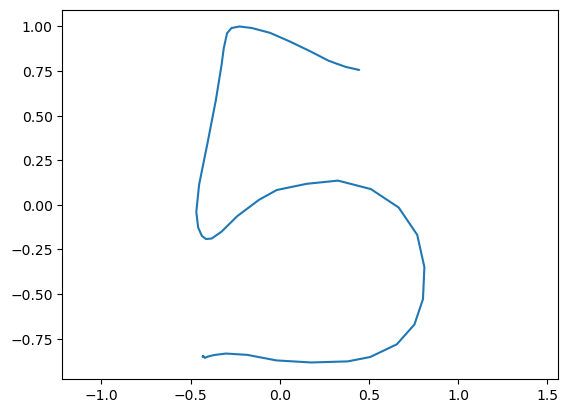

In [12]:
import os 
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

dir_path = "training_data"
file_paths = [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and "stroke_5" in f]

dfs = [pd.read_csv(f, header=None) for f in file_paths]

samples = []
for df in dfs[:5]: 

    # Scale data
    X = df.to_numpy()
    X_scaled = StandardScaler().fit_transform(X)

    # Fit PCA
    X_pca = PCA(n_components=2).fit_transform(X)
    
    # Scale the data to range [-1, 1]
    X_pca_scaled = X_pca / np.max(np.abs(X_pca))
    samples.append(X_pca_scaled)

    # Plot the reduced data
    plt.figure()
    plt.plot(X_pca_scaled[:, 1], X_pca_scaled[:, 0])
    plt.axis("equal")
    plt.show()

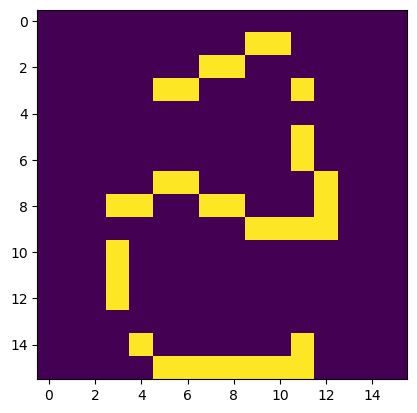

In [17]:
# Rescale samples
indices = [(((s + 1) / 2) * 15).astype(int) for s in samples]

# Prepare empty matrices for samples
X = [np.zeros([16, 16]) for _ in range(len(indices))]

for x, idx in zip(X, indices): 
    idx = -idx -1
    x[idx[:, 0], idx[:, 1]] = 1
    x = np.rot90(x, 2)

plt.imshow(X[3])